## Etapa 1 — Preparação e Importação de Dados

### 1. Bibliotecas

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


### 2. Criação e leitura do arquivo CSV

In [2]:
np.random.seed(42)
n = 240
datas = pd.date_range("2025-01-01", "2025-12-31", periods=n)
lojas = np.random.choice(["Loja Norte", "Loja Nordeste", "Loja Centro", "Loja Sul", "Loja Oeste"], n)
prod = np.random.choice(["Notebook", "Mouse", "Teclado", "Monitor", "Fone"], n)
precos = {"Notebook": 3500, "Mouse": 80, "Teclado": 150, "Monitor": 1200, "Fone": 220}
reg = {"Loja Norte": "Norte", "Loja Nordeste": "Nordeste", "Loja Centro": "Sudeste", "Loja Sul": "Sul", "Loja Oeste": "Centro-Oeste"}
cat = {"Notebook": "Informática", "Mouse": "Acessórios", "Teclado": "Acessórios", "Monitor": "Informática", "Fone": "Áudio"}

df = pd.DataFrame({
    "data": datas,
    "loja": lojas,
    "produto": prod,
    "quantidade": np.random.randint(1, 6, n),
    "preco_unitario": np.round([precos[p] for p in prod] * np.random.uniform(0.85, 1.15, n), 2)
})
df["regiao"] = df["loja"].map(reg)
df["categoria"] = df["produto"].map(cat)
df.loc[[7, 51, 123], "quantidade"] = np.nan
df.loc[[19, 88], "preco_unitario"] = np.nan
df.to_csv("vendas.csv", index=False, encoding="utf-8-sig")

df = pd.read_csv("vendas.csv")
df["data"] = pd.to_datetime(df["data"])
df.head()


,data,loja,produto,quantidade,preco_unitario,regiao,categoria
0,2025-01-01 00:00:00.000000000,Loja Sul,Teclado,1.0,145.15,Sul,Acessórios
1,2025-01-02 12:33:08.284518828,Loja Oeste,Notebook,4.0,3434.35,Centro-Oeste,Informática
2,2025-01-04 01:06:16.569037656,Loja Centro,Notebook,2.0,3924.37,Sudeste,Informática
3,2025-01-05 13:39:24.853556485,Loja Oeste,Teclado,5.0,143.17,Centro-Oeste,Acessórios
4,2025-01-07 02:12:33.138075313,Loja Oeste,Teclado,1.0,150.63,Centro-Oeste,Acessórios


### 3. Cálculo do faturamento

In [3]:
df["faturamento"] = df["quantidade"] * df["preco_unitario"]
df[["data", "loja", "produto", "quantidade", "preco_unitario", "faturamento"]].head()


,data,loja,produto,quantidade,preco_unitario,faturamento
0,2025-01-01 00:00:00.000000000,Loja Sul,Teclado,1.0,145.15,145.15
1,2025-01-02 12:33:08.284518828,Loja Oeste,Notebook,4.0,3434.35,13737.40
2,2025-01-04 01:06:16.569037656,Loja Centro,Notebook,2.0,3924.37,7848.74
3,2025-01-05 13:39:24.853556485,Loja Oeste,Teclado,5.0,143.17,715.85
4,2025-01-07 02:12:33.138075313,Loja Oeste,Teclado,1.0,150.63,150.63


### 4. Verificação da integridade dos dados

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            240 non-null    datetime64[ns]
 1   loja            240 non-null    object        
 2   produto         240 non-null    object        
 3   quantidade      237 non-null    float64       
 4   preco_unitario  238 non-null    float64       
 5   regiao          240 non-null    object        
 6   categoria       240 non-null    object        
 7   faturamento     235 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 15.1+ KB


In [5]:
df.isnull().sum()


data              0
loja              0
produto           0
quantidade        3
preco_unitario    2
regiao            0
categoria         0
faturamento       5
dtype: int64

In [6]:
df.describe()


,data,quantidade,preco_unitario,faturamento
count,240,237.000000,238.000000,235.000000
mean,2025-07-02 00:00:00,3.042194,1024.095924,3260.009404
min,2025-01-01 00:00:00,1.000000,68.480000,70.690000
25%,2025-04-02 00:00:00,2.000000,136.180000,301.600000
50%,2025-07-02 00:00:00,3.000000,217.510000,670.280000
75%,2025-10-01 00:00:00,4.000000,1287.030000,4452.380000
max,2025-12-31 00:00:00,5.000000,3992.940000,19964.700000
std,NaN,1.503637,1295.209640,4855.890160


### 5. Tratamento dos valores ausentes

In [7]:
df["quantidade"] = df["quantidade"].fillna(df["quantidade"].mean())
df["preco_unitario"] = df["preco_unitario"].fillna(df["preco_unitario"].mean())
df["faturamento"] = df["quantidade"] * df["preco_unitario"]
df.isnull().sum()


data              0
loja              0
produto           0
quantidade        0
preco_unitario    0
regiao            0
categoria         0
faturamento       0
dtype: int64

### 6. Faturamento total por loja

In [8]:
fat = df.groupby("loja")["faturamento"].sum().sort_values(ascending=False)
fat


loja
Loja Sul         244130.813715
Loja Nordeste    157915.100000
Loja Norte       149067.450000
Loja Oeste       139613.800000
Loja Centro      102074.569156
Name: faturamento, dtype: float64

### 7. Ticket médio por loja

In [9]:
vendas = df.groupby("loja")["faturamento"].count()
tkt = (fat / vendas).sort_values(ascending=False)
pd.DataFrame({"faturamento": fat, "vendas": vendas, "ticket_medio": fat / vendas}).sort_values("ticket_medio", ascending=False)


,faturamento,vendas,ticket_medio
loja,,,
Loja Sul,244130.813715,60,4068.846895
Loja Nordeste,157915.100000,42,3759.883333
Loja Oeste,139613.800000,39,3579.841026
Loja Norte,149067.450000,53,2812.593396
Loja Centro,102074.569156,46,2219.012373


### 8. Cinco produtos mais vendidos em quantidade

In [10]:
top = df.groupby("produto")["quantidade"].sum().sort_values(ascending=False).head(5)
top


produto
Monitor     165.000000
Mouse       155.000000
Notebook    152.084388
Fone        135.042194
Teclado     123.000000
Name: quantidade, dtype: float64

### 9. Mês com maior e menor faturamento

In [11]:
df["mes_ano"] = df["data"].dt.to_period("M")
fat_mes = df.groupby("mes_ano")["faturamento"].sum().sort_index()
mes_max = fat_mes.idxmax().strftime("%m/%Y")
mes_min = fat_mes.idxmin().strftime("%m/%Y")
print("Mês com maior faturamento:", mes_max, "— R$", round(fat_mes.max(), 2))
print("Mês com menor faturamento:", mes_min, "— R$", round(fat_mes.min(), 2))


Mês com maior faturamento: 03/2025 — R$ 94387.72
Mês com menor faturamento: 12/2025 — R$ 31720.06


### 10. Coluna com o mês extraído da data

In [12]:
df["mes"] = df["data"].dt.month
df[["data", "mes", "mes_ano"]].head()


,data,mes,mes_ano
0,2025-01-01 00:00:00.000000000,1,2025-01
1,2025-01-02 12:33:08.284518828,1,2025-01
2,2025-01-04 01:06:16.569037656,1,2025-01
3,2025-01-05 13:39:24.853556485,1,2025-01
4,2025-01-07 02:12:33.138075313,1,2025-01


### 17. Tema global e paleta de cores


In [13]:
sns.set_style("whitegrid")
sns.set_palette("deep")
os.makedirs("graficos", exist_ok=True)


### 18. Títulos, rótulos e legibilidade


### 11. Gráfico de barras — Faturamento por loja

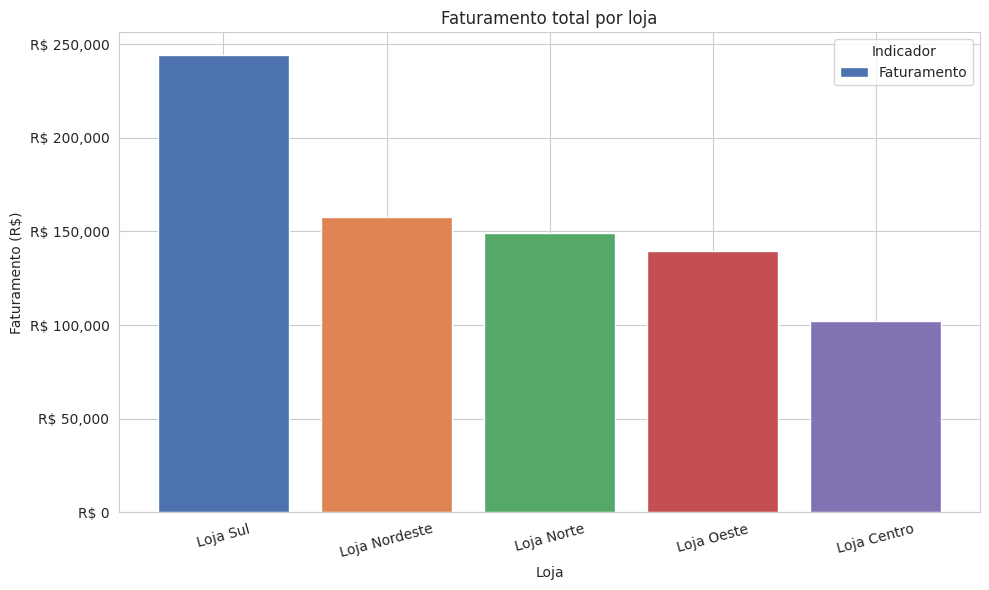

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(fat.index, fat.values, color=sns.color_palette("deep", len(fat)), label="Faturamento")
ax.set_title("Faturamento total por loja")
ax.set_xlabel("Loja")
ax.set_ylabel("Faturamento (R$)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.0f}"))
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Indicador")
fig.tight_layout()
fig.savefig("graficos/faturamento_por_loja.png", dpi=300, bbox_inches="tight")
plt.show()


### 12. Gráfico de linhas — Evolução mensal do faturamento

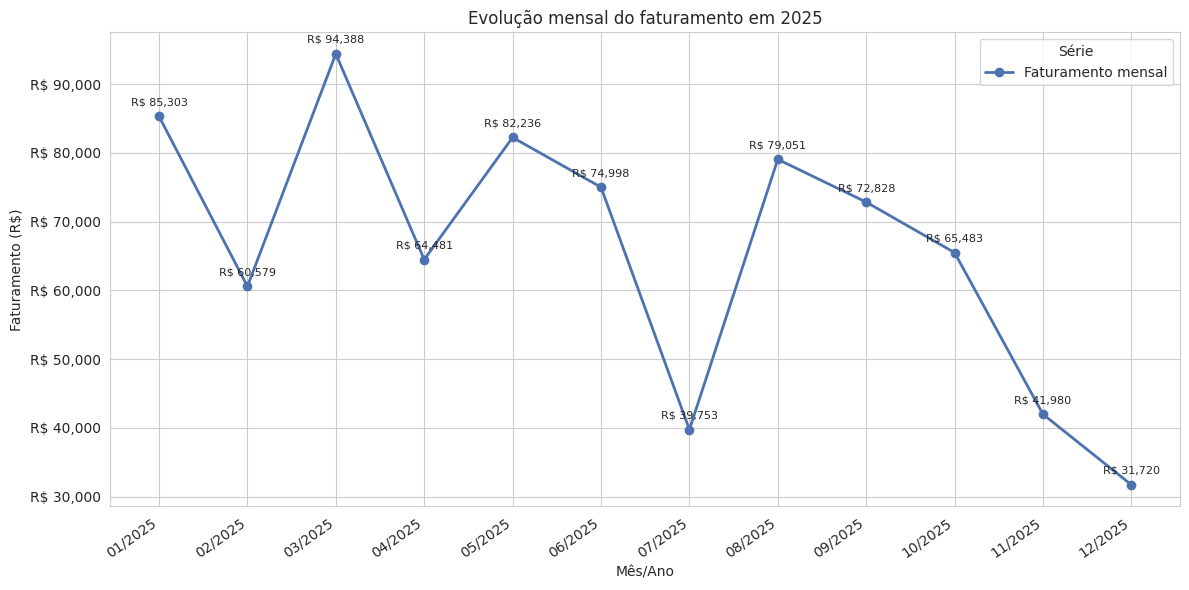

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(fat_mes))
lbl = fat_mes.index.strftime("%m/%Y")
ax.plot(x, fat_mes.values, marker="o", linewidth=2, label="Faturamento mensal")
for i, v in enumerate(fat_mes.values):
    ax.annotate(f"R$ {v:,.0f}", (i, v), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(lbl, rotation=35, ha="right")
ax.set_title("Evolução mensal do faturamento em 2025")
ax.set_xlabel("Mês/Ano")
ax.set_ylabel("Faturamento (R$)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.0f}"))
ax.legend(title="Série")
fig.tight_layout()
fig.savefig("graficos/evolucao_mensal.png", dpi=300, bbox_inches="tight")
plt.show()


### 13. Gráfico de pizza — Faturamento por região

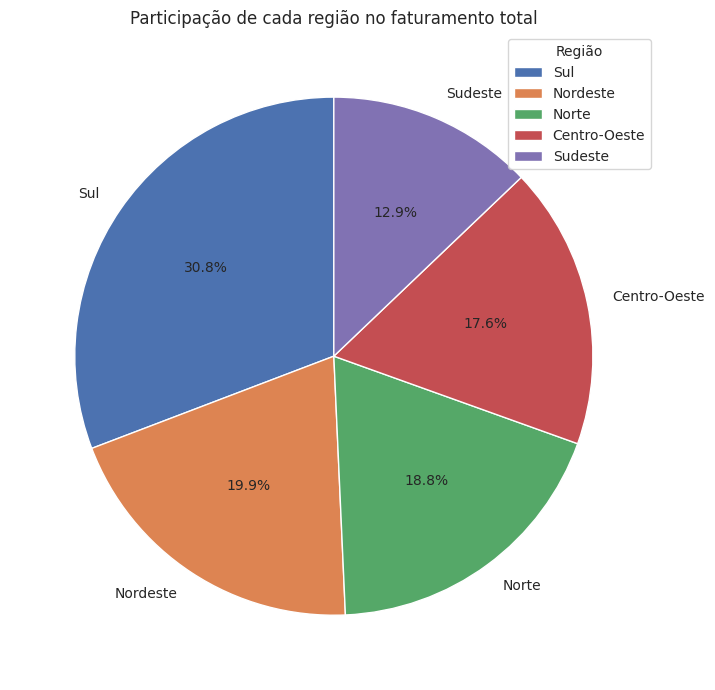

In [16]:
fat_reg = df.groupby("regiao")["faturamento"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 7))
ax.pie(fat_reg.values, labels=fat_reg.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("deep", len(fat_reg)))
ax.set_title("Participação de cada região no faturamento total")
ax.legend(fat_reg.index, title="Região", loc="best")
fig.tight_layout()
fig.savefig("graficos/faturamento_por_regiao.png", dpi=300, bbox_inches="tight")
plt.show()


### 14. Gráfico de dispersão — Quantidade e faturamento

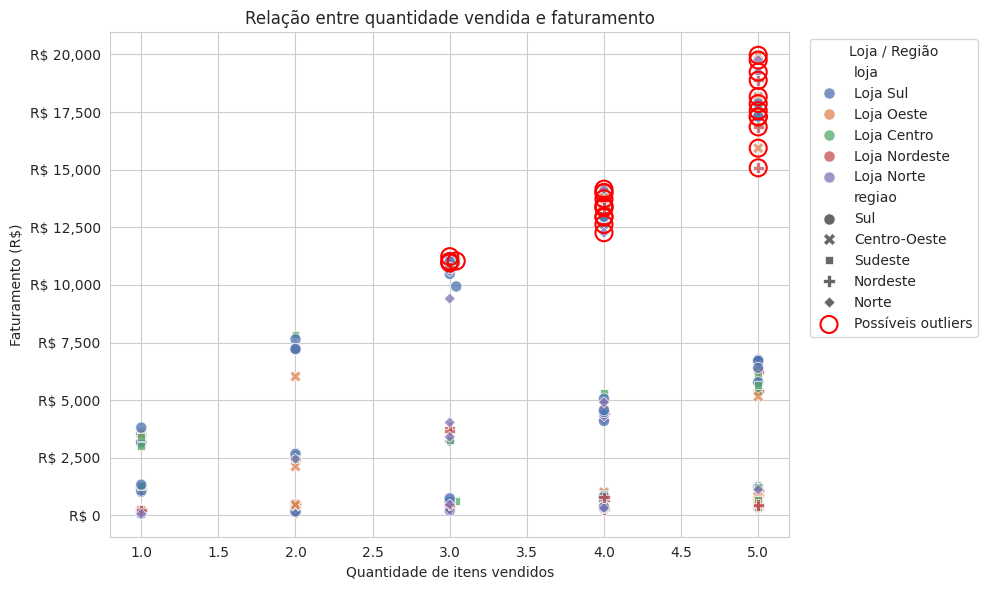

In [17]:
q1 = df["faturamento"].quantile(0.25)
q3 = df["faturamento"].quantile(0.75)
lim = q3 + 1.5 * (q3 - q1)
out = df[df["faturamento"] > lim]
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x="quantidade", y="faturamento", hue="loja", style="regiao", s=65, alpha=0.75, ax=ax)
if not out.empty:
    ax.scatter(out["quantidade"], out["faturamento"], facecolors="none", edgecolors="red", s=150, linewidth=1.5, label="Possíveis outliers")
ax.set_title("Relação entre quantidade vendida e faturamento")
ax.set_xlabel("Quantidade de itens vendidos")
ax.set_ylabel("Faturamento (R$)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.0f}"))
ax.legend(title="Loja / Região", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig("graficos/quantidade_faturamento.png", dpi=300, bbox_inches="tight")
plt.show()


### 15. Boxplot — Distribuição de preços por categoria

/tmp/ipykernel_355/4147239926.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Categoria", bbox_to_anchor=(1.02, 1), loc="upper left")


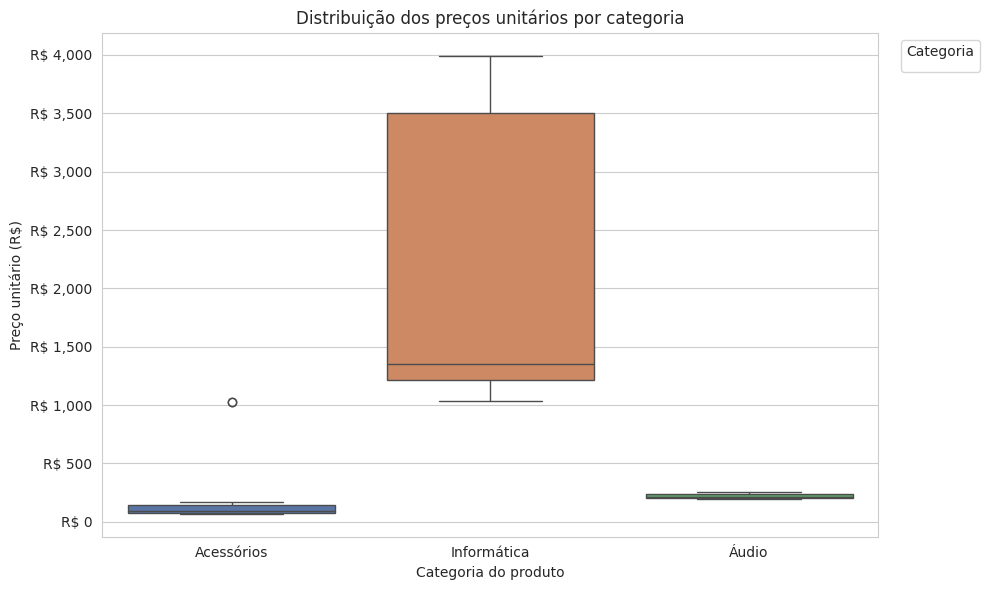

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x="categoria", y="preco_unitario", hue="categoria", dodge=False, palette="deep", ax=ax)
ax.set_title("Distribuição dos preços unitários por categoria")
ax.set_xlabel("Categoria do produto")
ax.set_ylabel("Preço unitário (R$)")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.0f}"))
ax.legend(title="Categoria", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig("graficos/precos_por_categoria.png", dpi=300, bbox_inches="tight")
plt.show()


### 16. Heatmap — Correlação entre variáveis numéricas

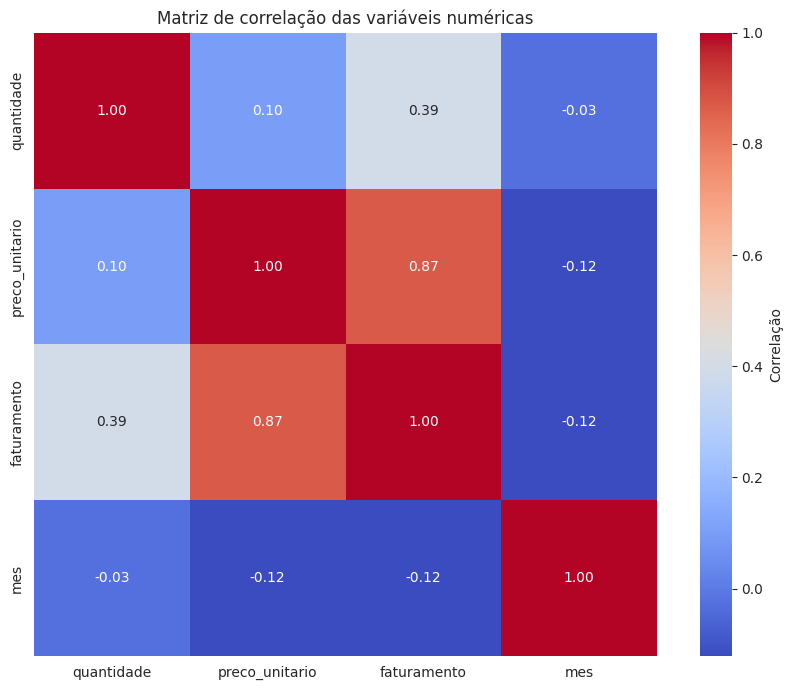

In [19]:
corr = df[["quantidade", "preco_unitario", "faturamento", "mes"]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"label": "Correlação"}, ax=ax)
ax.set_title("Matriz de correlação das variáveis numéricas")
fig.tight_layout()
fig.savefig("graficos/correlacao_variaveis.png", dpi=300, bbox_inches="tight")
plt.show()


### 19. Layout — Comparação entre lojas e regiões

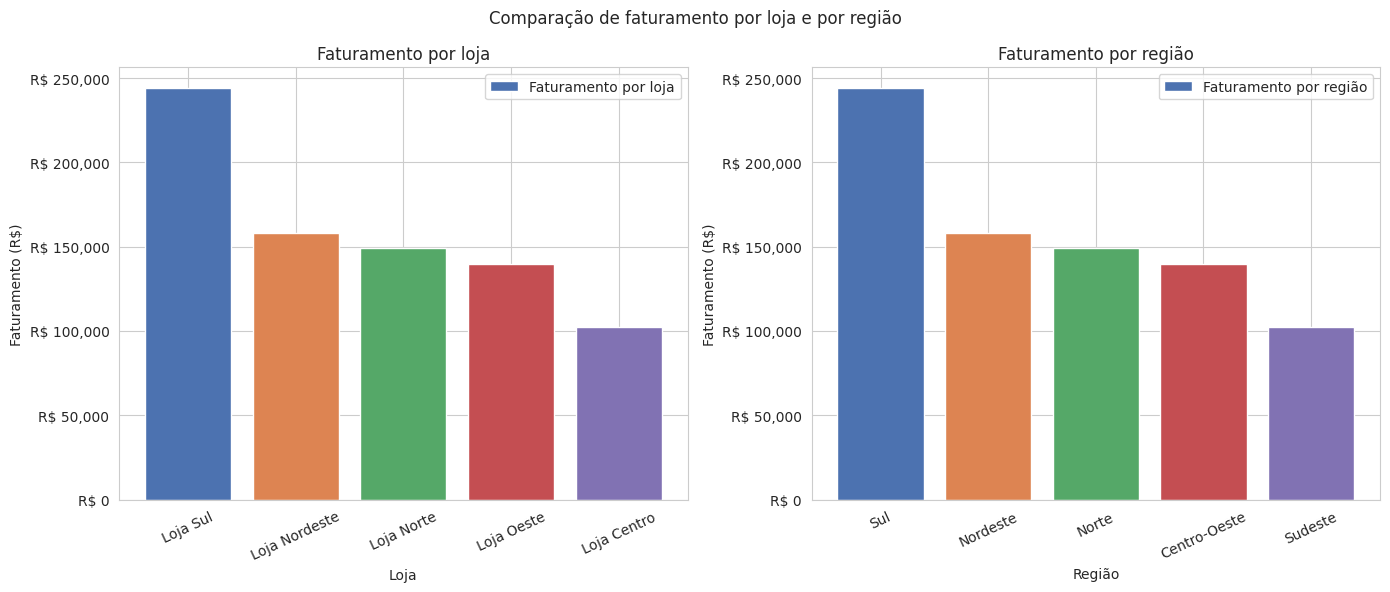

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].bar(fat.index, fat.values, color=sns.color_palette("deep", len(fat)), label="Faturamento por loja")
ax[0].set_title("Faturamento por loja")
ax[0].set_xlabel("Loja")
ax[0].set_ylabel("Faturamento (R$)")
ax[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.0f}"))
ax[0].tick_params(axis="x", rotation=25)
ax[0].legend()
ax[1].bar(fat_reg.index, fat_reg.values, color=sns.color_palette("deep", len(fat_reg)), label="Faturamento por região")
ax[1].set_title("Faturamento por região")
ax[1].set_xlabel("Região")
ax[1].set_ylabel("Faturamento (R$)")
ax[1].yaxis.set_major_formatter(mtick.StrMethodFormatter("R$ {x:,.0f}"))
ax[1].tick_params(axis="x", rotation=25)
ax[1].legend()
fig.suptitle("Comparação de faturamento por loja e por região")
fig.tight_layout()
fig.savefig("graficos/comparacao_loja_regiao.png", dpi=300, bbox_inches="tight")
plt.show()


### 20. Exportação e relatório final

In [21]:
r_loja = df.groupby("loja").agg(faturamento=("faturamento", "sum"), quantidade=("quantidade", "sum"), vendas=("faturamento", "count"), ticket_medio=("faturamento", "mean")).reset_index().rename(columns={"loja": "grupo"})
r_loja["tipo"] = "Loja"
r_reg = df.groupby("regiao").agg(faturamento=("faturamento", "sum"), quantidade=("quantidade", "sum"), vendas=("faturamento", "count"), ticket_medio=("faturamento", "mean")).reset_index().rename(columns={"regiao": "grupo"})
r_reg["tipo"] = "Região"
r_mes = df.groupby("mes_ano").agg(faturamento=("faturamento", "sum"), quantidade=("quantidade", "sum"), vendas=("faturamento", "count"), ticket_medio=("faturamento", "mean")).reset_index().rename(columns={"mes_ano": "grupo"})
r_mes["grupo"] = r_mes["grupo"].astype(str)
r_mes["tipo"] = "Mês"
r_prod = df.groupby("produto").agg(faturamento=("faturamento", "sum"), quantidade=("quantidade", "sum"), vendas=("faturamento", "count"), ticket_medio=("faturamento", "mean")).reset_index().rename(columns={"produto": "grupo"})
r_prod["tipo"] = "Produto"
cols = ["tipo", "grupo", "faturamento", "quantidade", "vendas", "ticket_medio"]
res = pd.concat([r_loja[cols], r_reg[cols], r_mes[cols], r_prod[cols]], ignore_index=True)
res.to_csv("resumo_analitico.csv", index=False, encoding="utf-8-sig", decimal=",")
print("Arquivo gerado: resumo_analitico.csv")
print("Gráficos salvos:", len([f for f in os.listdir("graficos") if f.endswith(".png")]))
print("Loja com maior faturamento:", fat.idxmax())
print("Região com maior faturamento:", fat_reg.idxmax())
print("Produto mais vendido:", top.index[0])
print("Mês com maior faturamento:", mes_max)
print("Mês com menor faturamento:", mes_min)
res.head(10)


Arquivo gerado: resumo_analitico.csv
Gráficos salvos: 7
Loja com maior faturamento: Loja Sul
Região com maior faturamento: Sul
Produto mais vendido: Monitor
Mês com maior faturamento: 03/2025
Mês com menor faturamento: 12/2025


,tipo,grupo,faturamento,quantidade,vendas,ticket_medio
0,Loja,Loja Centro,102074.569156,131.084388,46,2219.012373
1,Loja,Loja Nordeste,157915.100000,139.000000,42,3759.883333
2,Loja,Loja Norte,149067.450000,160.000000,53,2812.593396
3,Loja,Loja Oeste,139613.800000,123.000000,39,3579.841026
4,Loja,Loja Sul,244130.813715,177.042194,60,4068.846895
5,Região,Centro-Oeste,139613.800000,123.000000,39,3579.841026
6,Região,Nordeste,157915.100000,139.000000,42,3759.883333
7,Região,Norte,149067.450000,160.000000,53,2812.593396
8,Região,Sudeste,102074.569156,131.084388,46,2219.012373
9,Região,Sul,244130.813715,177.042194,60,4068.846895
